# ecDNA / HSR integration window scan

This notebook:

1. Reads **normalized** Hi-C contact data from two `.mcool` files (**HSR** and **regular ecDNA**)
2. Reads ecDNA intervals from BED / cycle files
3. Computes **ecDNA→genome 1D interaction profiles** **block by block** (no full matrix load, no coarse-graining)
4. Finds **significant windows** in **both** HSR and regular Hi-C using a one-sided Mann–Whitney/Wilcoxon rank-sum test against local background
5. Computes **HSR vs regular log2 fold change**
6. Filters candidate windows using:
   - `q_HSR < QVAL_THRESHOLD`
   - `log2FC_HSR_vs_REG > LOG2FC_THRESHOLD`
7. Maps top candidate bins back to **genomic coordinates**

Update the paths and parameters in the config cell, then run all cells.


In [9]:

import os
import time
import warnings
import numpy as np
import pandas as pd
import cooler
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130


In [10]:

# =========================
# CONFIG
# =========================

BASE_DIR = r"C:\Users\ronit\Downloads\CSE_280A_Project"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

RESOLUTION = 25000

HSR = dict(
    cool=f"{DATA_DIR}/GBM39HSR.mcool::resolutions/{RESOLUTION}",
    bed=f"{DATA_DIR}/GBM39HSR_ecDNA.bed",
    label="GBM39 HSR",
)

REG = dict(
    cool=f"{DATA_DIR}/GBM39ec.mcool::resolutions/{RESOLUTION}",
    bed=f"{DATA_DIR}/GBM39_ecDNA.bed",
    label="GBM39 ecDNA",
)

# Choose a normalization column present in the bins table.
# Available in your data: KR, SCALE, VC, VC_SQRT
BALANCE = "SCALE"

# Window scan parameters
EPS = 1e-8
WINDOW_RADIUS = 2          # signal window = 2*WINDOW_RADIUS + 1 bins
BACKGROUND_RADIUS = 20     # local background radius
USE_MEDIAN = True          # summarize window log2FC by median instead of mean
TOP_K = 25

# Filtering thresholds
QVAL_THRESHOLD = 0.05
LOG2FC_THRESHOLD = 1.0     # 1.0 => HSR is at least 2x stronger than regular

_ORDERED = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]


In [11]:

# =========================
# ecDNA interval reader
# =========================
try:
    from ec3d.util import read_ecDNA_cycle
except ImportError:
    try:
        from util import read_ecDNA_cycle
    except ImportError:
        def read_ecDNA_cycle(path, resolution):
            intervals = []
            with open(path) as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#"):
                        continue
                    parts = line.split()
                    chrom = parts[0]
                    start = (int(parts[1]) // resolution) * resolution
                    end = ((int(parts[2]) + resolution - 1) // resolution) * resolution
                    ori = parts[3] if len(parts) > 3 else "+"
                    intervals.append((chrom, start, end, ori))
            return intervals

# =========================
# Helpers
# =========================
def ordered_chroms(clr_chromnames):
    names = set(clr_chromnames) - {"chrM", "M"}
    result = [c for c in _ORDERED if c in names]
    result += sorted(names - set(result))
    return result

def resolve_chrom_name(chrom, clr_chromnames):
    names = set(clr_chromnames)
    if chrom in names:
        return chrom
    if chrom.startswith("chr") and chrom[3:] in names:
        return chrom[3:]
    if (not chrom.startswith("chr")) and ("chr" + chrom) in names:
        return "chr" + chrom
    return None

def interval_to_str(chrom, start, end):
    return f"{chrom}:{start}-{end}"

def get_balance_col(clr, balance):
    cols = list(clr.bins()[:].columns)
    if balance not in cols:
        available = [c for c in cols if c not in ("chrom", "start", "end")]
        raise ValueError(
            f"Normalization column '{balance}' not found in {clr.filename}. "
            f"Available columns: {available}"
        )
    return balance

def get_weight_array(df, balance):
    w = df[balance].to_numpy(dtype=np.float64)
    return np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)

def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    qvals = np.empty(n, dtype=float)

    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * n / rank
        prev = min(prev, q)
        qvals[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(qvals, 0, 1)
    return out

def extract_signal_and_background(profile: np.ndarray, center: int,
                                  window_radius: int,
                                  background_radius: int):
    n = len(profile)
    left = max(0, center - background_radius)
    right = min(n, center + background_radius + 1)

    sig_left = max(0, center - window_radius)
    sig_right = min(n, center + window_radius + 1)

    signal = profile[sig_left:sig_right]

    bg_left = profile[left:sig_left]
    bg_right = profile[sig_right:right]
    background = np.concatenate([bg_left, bg_right])

    return signal, background, sig_left, sig_right

def score_windows(profile: np.ndarray,
                  window_radius: int,
                  background_radius: int):
    results = []
    for center in range(len(profile)):
        signal, background, sig_left, sig_right = extract_signal_and_background(
            profile, center, window_radius, background_radius
        )

        if len(signal) < 2 or len(background) < 5:
            results.append((center, np.nan, np.nan, np.nan, sig_left, sig_right))
            continue

        try:
            _, pval = mannwhitneyu(signal, background, alternative="greater")
        except ValueError:
            pval = np.nan

        signal_mean = np.mean(signal)
        background_mean = np.mean(background)
        results.append((center, pval, signal_mean, background_mean, sig_left, sig_right))

    centers = np.array([r[0] for r in results], dtype=int)
    pvals = np.array([r[1] for r in results], dtype=float)
    signal_means = np.array([r[2] for r in results], dtype=float)
    background_means = np.array([r[3] for r in results], dtype=float)
    sig_lefts = np.array([r[4] for r in results], dtype=int)
    sig_rights = np.array([r[5] for r in results], dtype=int)

    qvals = np.full_like(pvals, np.nan)
    valid = ~np.isnan(pvals)
    if np.any(valid):
        qvals[valid] = bh_fdr(pvals[valid])

    neglog10p = -np.log10(np.clip(pvals, 1e-300, 1.0))
    neglog10q = -np.log10(np.clip(qvals, 1e-300, 1.0))

    return dict(
        centers=centers,
        pvals=pvals,
        qvals=qvals,
        neglog10p=neglog10p,
        neglog10q=neglog10q,
        signal_means=signal_means,
        background_means=background_means,
        sig_lefts=sig_lefts,
        sig_rights=sig_rights,
    )

def save_window_results(path, stats_dict, extra_cols=None):
    df = pd.DataFrame({
        "center_bin": stats_dict["centers"],
        "window_start": stats_dict["sig_lefts"],
        "window_end": stats_dict["sig_rights"] - 1,
        "pval": stats_dict["pvals"],
        "qval": stats_dict["qvals"],
        "neglog10p": stats_dict["neglog10p"],
        "neglog10q": stats_dict["neglog10q"],
        "signal_mean": stats_dict["signal_means"],
        "background_mean": stats_dict["background_means"],
    })
    if extra_cols is not None:
        for k, v in extra_cols.items():
            df[k] = v
    df.to_csv(path, sep="\t", index=False)
    print(f"Saved: {path}")
    return df


In [12]:

# =========================
# Block-wise ecDNA→genome profile extraction
# =========================
def prepare_intervals(clr, bed_path, resolution, balance):
    raw_intrvls = read_ecDNA_cycle(bed_path, resolution)
    resolved = []

    for chrom, start, end, ori in raw_intrvls:
        ch = resolve_chrom_name(chrom, clr.chromnames)
        if ch is None:
            print(f"WARNING: interval {chrom}:{start}-{end} not found in cooler; skipping.")
            continue

        region = interval_to_str(ch, start, end)
        try:
            bins_df = clr.bins().fetch(region)
        except Exception:
            print(f"WARNING: could not fetch {region}; skipping.")
            continue

        if len(bins_df) == 0:
            continue

        weights = get_weight_array(bins_df, balance)
        resolved.append({
            "chrom": ch,
            "start": start,
            "end": end,
            "ori": ori,
            "region": region,
            "n_bins": len(bins_df),
            "weights": weights
        })

    if not resolved:
        raise ValueError(f"No valid ecDNA intervals found in {bed_path}")

    total_ec_bins = sum(r["n_bins"] for r in resolved)
    print(f"  Loaded {len(resolved)} ecDNA interval(s), total ecDNA bins = {total_ec_bins}")
    return resolved, total_ec_bins

def build_ec_vs_genome_profile(clr, intrvls_prepared, total_ec_bins, balance, chroms):
    """
    profile[j] = mean normalized interaction between all ecDNA bins and genome bin j
    computed chromosome-by-chromosome, interval-by-interval.
    """
    profile_parts = []
    chrom_offsets = {}
    cursor = 0

    print("  Building ecDNA→genome profile block by block ...")
    t0 = time.time()

    for ch_idx, ch in enumerate(chroms):
        chr_bins_df = clr.bins().fetch(ch)
        n_chr_bins = len(chr_bins_df)
        chrom_offsets[ch] = cursor
        cursor += n_chr_bins

        col_weights = get_weight_array(chr_bins_df, balance)
        chrom_sum = np.zeros(n_chr_bins, dtype=np.float64)

        for intr in intrvls_prepared:
            region = intr["region"]
            row_weights = intr["weights"]

            try:
                block = clr.matrix(balance=False, sparse=True).fetch(region, ch)
            except Exception as e:
                print(f"    WARNING: failed to fetch block {region} vs {ch}: {e}")
                continue

            if block.nnz == 0:
                continue

            vals = block.data.astype(np.float64)
            vals = vals * row_weights[block.row] * col_weights[block.col]

            np.add.at(chrom_sum, block.col, vals)

        chrom_profile = chrom_sum / max(total_ec_bins, 1)
        profile_parts.append(chrom_profile)

        print(
            f"    {ch_idx+1:2d}/{len(chroms)}  {ch:>5s}  bins={n_chr_bins:>7,d}  "
            f"time={time.time()-t0:.1f}s",
            flush=True
        )

    profile = np.concatenate(profile_parts)
    return profile, chrom_offsets

def build_bin_table(clr, chroms):
    dfs = []
    for ch in chroms:
        df = clr.bins().fetch(ch)[["chrom", "start", "end"]].copy()
        dfs.append(df)
    out = pd.concat(dfs, axis=0, ignore_index=True)
    out["genome_bin_index"] = np.arange(len(out))
    return out


In [13]:

# =========================
# Load data and build profiles
# =========================
print("=" * 80)
print("Loading coolers...")

clr_hsr = cooler.Cooler(HSR["cool"])
clr_reg = cooler.Cooler(REG["cool"])

if clr_hsr.binsize != RESOLUTION or clr_reg.binsize != RESOLUTION:
    raise ValueError(
        f"Resolution mismatch: HSR={clr_hsr.binsize}, REG={clr_reg.binsize}, CONFIG={RESOLUTION}"
    )

get_balance_col(clr_hsr, BALANCE)
get_balance_col(clr_reg, BALANCE)

chroms_hsr = ordered_chroms(clr_hsr.chromnames)
chroms_reg = ordered_chroms(clr_reg.chromnames)
chroms = [c for c in chroms_hsr if c in set(chroms_reg)]

print(f"Using chromosomes ({len(chroms)}): {chroms}")
print(f"Normalization column: {BALANCE}\n")

print(f"Preparing ecDNA intervals for {HSR['label']} ...")
hsr_intrvls, hsr_total_ec_bins = prepare_intervals(clr_hsr, HSR["bed"], RESOLUTION, BALANCE)

print(f"Preparing ecDNA intervals for {REG['label']} ...")
reg_intrvls, reg_total_ec_bins = prepare_intervals(clr_reg, REG["bed"], RESOLUTION, BALANCE)
print()

print(f"Computing profile for {HSR['label']} ...")
hsr_profile, _ = build_ec_vs_genome_profile(
    clr_hsr, hsr_intrvls, hsr_total_ec_bins, BALANCE, chroms
)

print(f"\nComputing profile for {REG['label']} ...")
reg_profile, _ = build_ec_vs_genome_profile(
    clr_reg, reg_intrvls, reg_total_ec_bins, BALANCE, chroms
)

if len(hsr_profile) != len(reg_profile):
    raise ValueError(
        f"Profile length mismatch: HSR={len(hsr_profile)}, REG={len(reg_profile)}"
    )

np.save(os.path.join(RESULTS_DIR, "hsr_ec_vs_genome_profile.npy"), hsr_profile)
np.save(os.path.join(RESULTS_DIR, "reg_ec_vs_genome_profile.npy"), reg_profile)

bins_df = build_bin_table(clr_hsr, chroms)
bins_df.to_csv(os.path.join(RESULTS_DIR, "genome_bin_annotations.tsv"), sep="\t", index=False)

print("\nProfiles saved.")
print("Profile length:", len(hsr_profile))
print("First 10 HSR values:", hsr_profile[:10])
print("First 10 regular values:", reg_profile[:10])


Loading coolers...
Using chromosomes (24): ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY']
Normalization column: SCALE

Preparing ecDNA intervals for GBM39 HSR ...
  Loaded 3 ecDNA interval(s), total ecDNA bins = 53
Preparing ecDNA intervals for GBM39 ecDNA ...
  Loaded 3 ecDNA interval(s), total ecDNA bins = 53

Computing profile for GBM39 HSR ...
  Building ecDNA→genome profile block by block ...
     1/24   chr1  bins=  9,959  time=3.1s
     2/24   chr2  bins=  9,688  time=6.7s
     3/24   chr3  bins=  7,932  time=10.7s
     4/24   chr4  bins=  7,609  time=12.8s
     5/24   chr5  bins=  7,262  time=14.3s
     6/24   chr6  bins=  6,833  time=15.6s
     7/24   chr7  bins=  6,374  time=16.4s
     8/24   chr8  bins=  5,806  time=16.5s
     9/24   chr9  bins=  5,536  time=16.6s
    10/24  chr10  bins=  5,352  time=16.8s
    11/24  c

In [14]:

# =========================
# Window significance + HSR vs regular comparison
# =========================
print("Scoring windows in HSR profile ...")
hsr_stats = score_windows(hsr_profile, WINDOW_RADIUS, BACKGROUND_RADIUS)

print("Scoring windows in regular ecDNA profile ...")
reg_stats = score_windows(reg_profile, WINDOW_RADIUS, BACKGROUND_RADIUS)

per_bin_log2fc = np.log2((hsr_profile + EPS) / (reg_profile + EPS))

window_log2fc = np.full(len(hsr_profile), np.nan, dtype=float)
for i in range(len(hsr_profile)):
    left = hsr_stats["sig_lefts"][i]
    right = hsr_stats["sig_rights"][i]
    vals = per_bin_log2fc[left:right]
    if len(vals) == 0:
        continue
    window_log2fc[i] = np.median(vals) if USE_MEDIAN else np.mean(vals)

# Suggested candidate rule:
#   significant in HSR by q-value
#   sufficiently stronger in HSR than regular by log2FC
candidate_mask = (
    np.isfinite(hsr_stats["qvals"]) &
    (hsr_stats["qvals"] < QVAL_THRESHOLD) &
    np.isfinite(window_log2fc) &
    (window_log2fc > LOG2FC_THRESHOLD)
)

candidate_score = np.where(candidate_mask, window_log2fc, np.nan)

# Save result tables
hsr_df = save_window_results(
    os.path.join(RESULTS_DIR, "hsr_window_scan_results.tsv"),
    hsr_stats,
    extra_cols={
        "window_log2fc_hsr_vs_reg": window_log2fc,
        "candidate_mask": candidate_mask,
        "candidate_score": candidate_score,
    }
)

reg_df = save_window_results(
    os.path.join(RESULTS_DIR, "reg_window_scan_results.tsv"),
    reg_stats
)

print(f"\nHSR q<{QVAL_THRESHOLD}: {(hsr_stats['qvals'] < QVAL_THRESHOLD).sum()} windows")
print(f"HSR q<{QVAL_THRESHOLD} and log2FC>{LOG2FC_THRESHOLD}: {candidate_mask.sum()} windows")


Scoring windows in HSR profile ...
Scoring windows in regular ecDNA profile ...
Saved: C:\Users\ronit\Downloads\CSE_280A_Project\results\hsr_window_scan_results.tsv
Saved: C:\Users\ronit\Downloads\CSE_280A_Project\results\reg_window_scan_results.tsv

HSR q<0.05: 24 windows
HSR q<0.05 and log2FC>1.0: 20 windows


In [15]:

# =========================
# Map top candidate bins to genomic coordinates
# =========================
bins_lookup = bins_df.set_index("genome_bin_index")

candidate_centers = hsr_stats["centers"][candidate_mask]
candidate_scores = candidate_score[candidate_mask]

order = np.argsort(candidate_scores)[::-1]
top_centers = candidate_centers[order][:TOP_K]

top_rows = []
for c in top_centers:
    i = int(c)
    row = bins_lookup.loc[i]
    top_rows.append({
        "center_bin": i,
        "chrom": row["chrom"],
        "start": int(row["start"]),
        "end": int(row["end"]),
        "window_start_bin": int(hsr_stats["sig_lefts"][i]),
        "window_end_bin": int(hsr_stats["sig_rights"][i] - 1),
        "pval_hsr": float(hsr_stats["pvals"][i]),
        "qval_hsr": float(hsr_stats["qvals"][i]),
        "neglog10p_hsr": float(hsr_stats["neglog10p"][i]),
        "window_log2fc_hsr_vs_reg": float(window_log2fc[i]),
        "hsr_signal_mean": float(hsr_stats["signal_means"][i]),
        "hsr_background_mean": float(hsr_stats["background_means"][i]),
        "candidate_score": float(candidate_score[i]),
        "reg_qval_same_window": float(reg_stats["qvals"][i]) if np.isfinite(reg_stats["qvals"][i]) else np.nan,
    })

top_df = pd.DataFrame(top_rows)
top_path = os.path.join(RESULTS_DIR, "top_candidate_integration_windows.tsv")
top_df.to_csv(top_path, sep="\t", index=False)

print(f"Saved: {top_path}")
top_df


Saved: C:\Users\ronit\Downloads\CSE_280A_Project\results\top_candidate_integration_windows.tsv


,center_bin,chrom,start,end,window_start_bin,window_end_bin,pval_hsr,qval_hsr,neglog10p_hsr,window_log2fc_hsr_vs_reg,hsr_signal_mean,hsr_background_mean,candidate_score,reg_qval_same_window
0,92626,chr15,17050000,17075000,92624,92628,2.459676e-06,0.027476,5.609122,24.761154,0.243372,0.000235,24.761154,0.606652
1,92625,chr15,17025000,17050000,92623,92627,2.459676e-06,0.027476,5.609122,24.761154,0.243372,0.000235,24.761154,0.606652
2,48545,chr6,152375000,152400000,48543,48547,5.337618e-06,0.038789,5.272653,3.490492,9.504631,3.961760,3.490492,0.310839
3,64364,chr9,72525000,72550000,64362,64366,5.337618e-06,0.038789,5.272653,3.423253,7.681619,2.960172,3.423253,0.442307
4,25879,chr3,155800000,155825000,25877,25881,2.668809e-06,0.027476,5.573683,3.002478,10.080646,5.899263,3.002478,0.578651
5,77260,chr11,122725000,122750000,77258,77262,9.340831e-06,0.048082,5.029614,2.919113,8.777348,4.812195,2.919113,0.391515
6,48546,chr6,152400000,152425000,48544,48548,2.668809e-06,0.027476,5.573683,2.908768,9.763227,3.996664,2.908768,0.176074
7,80264,chr12,62725000,62750000,80262,80266,9.340831e-06,0.048082,5.029614,2.695311,7.252265,2.795953,2.695311,0.065962
8,78528,chr12,19325000,19350000,78526,78530,2.668809e-06,0.027476,5.573683,2.693945,5.014971,1.752963,2.693945,0.373340
9,5902,chr1,147550000,147575000,5900,5904,1.334404e-06,0.027476,5.874713,2.520677,6.288616,3.092655,2.520677,0.519005


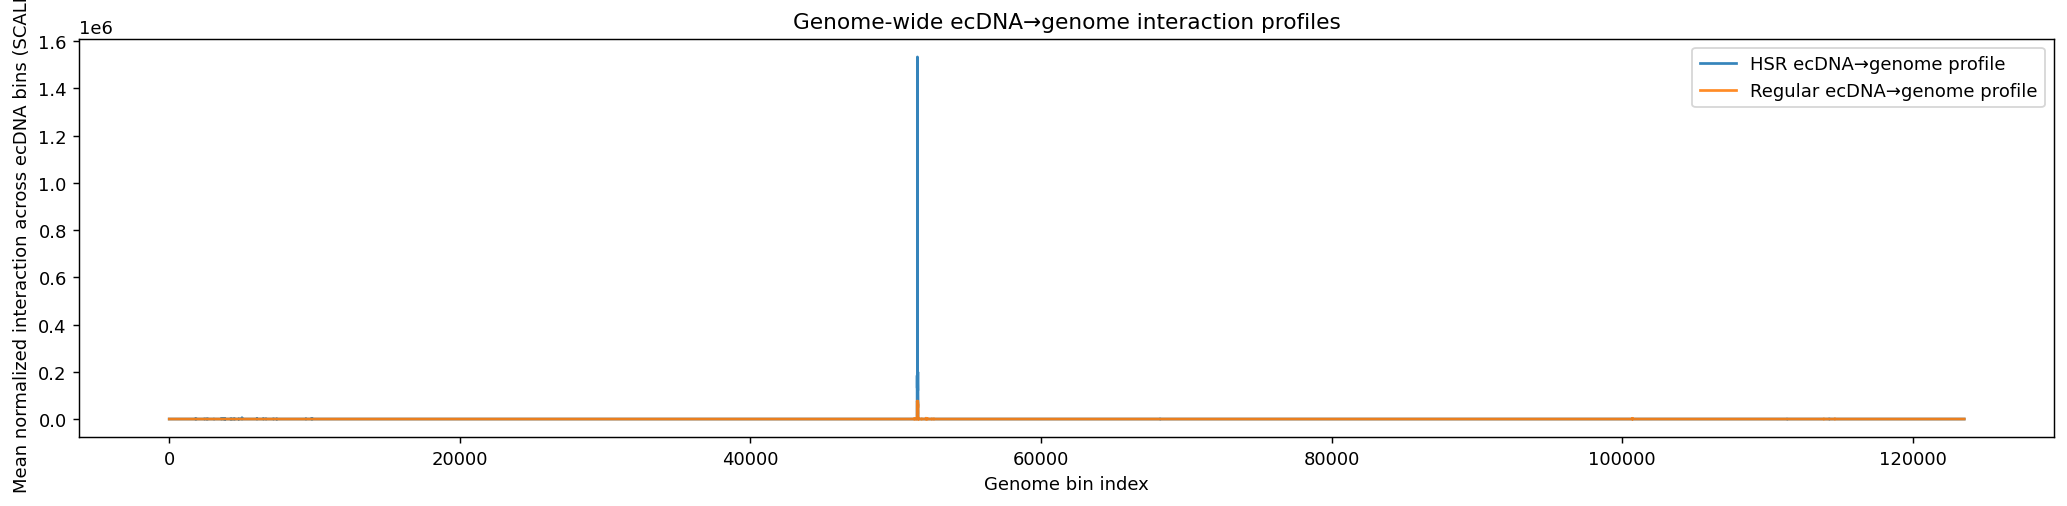

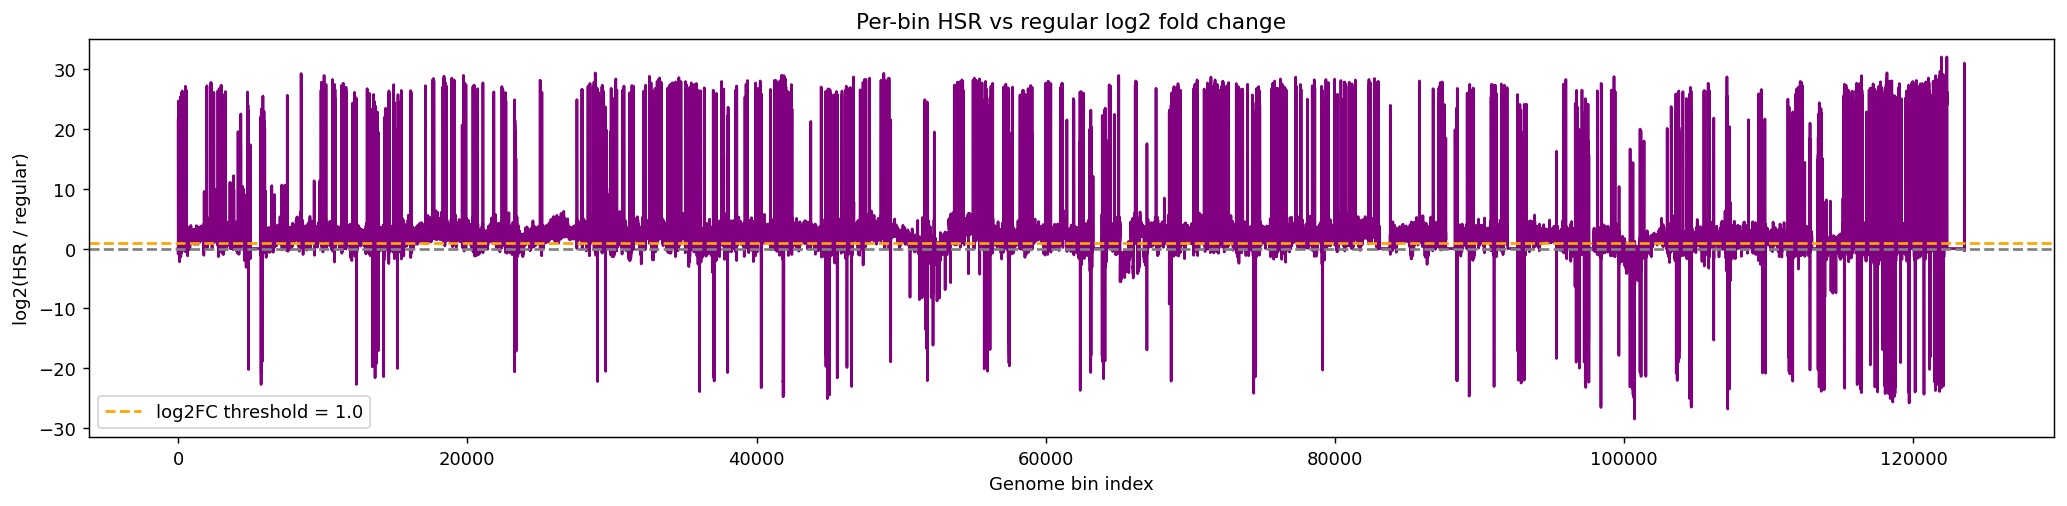

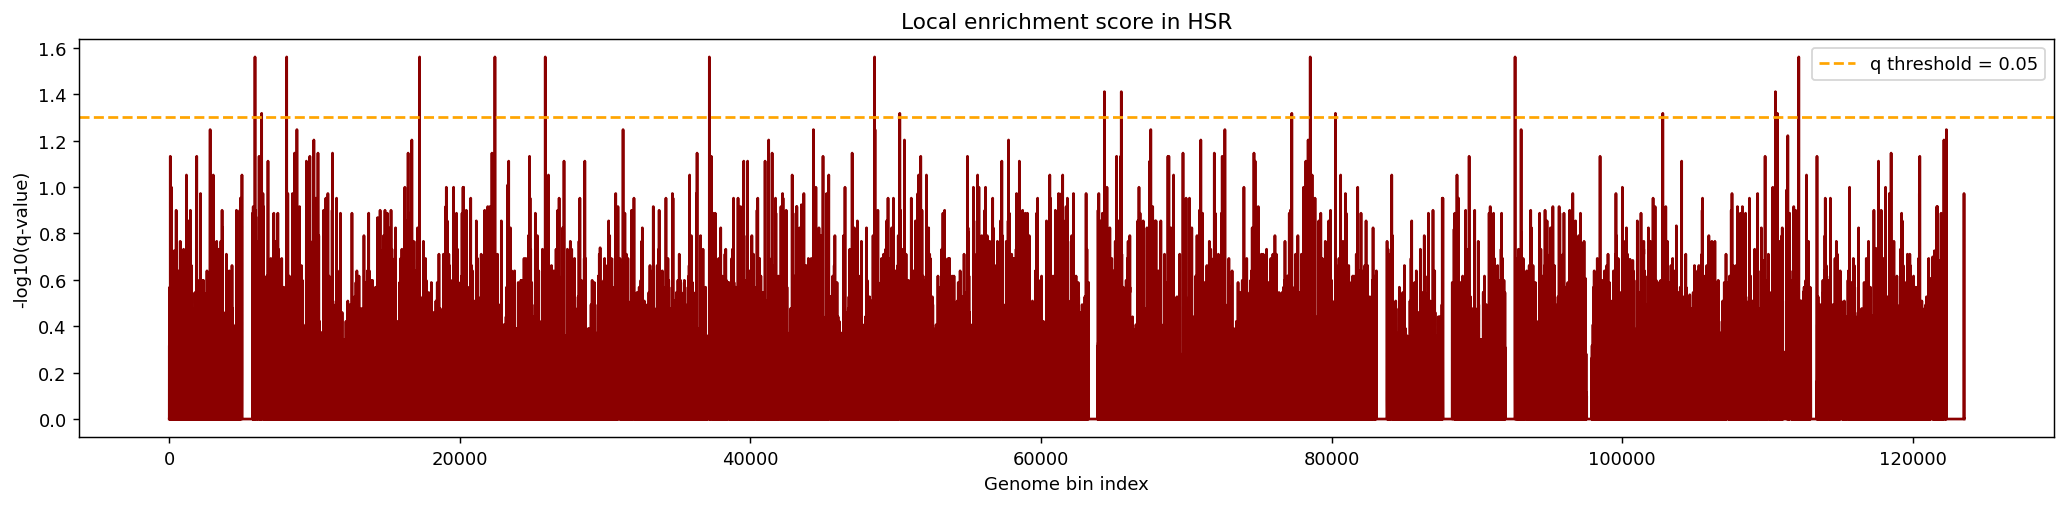

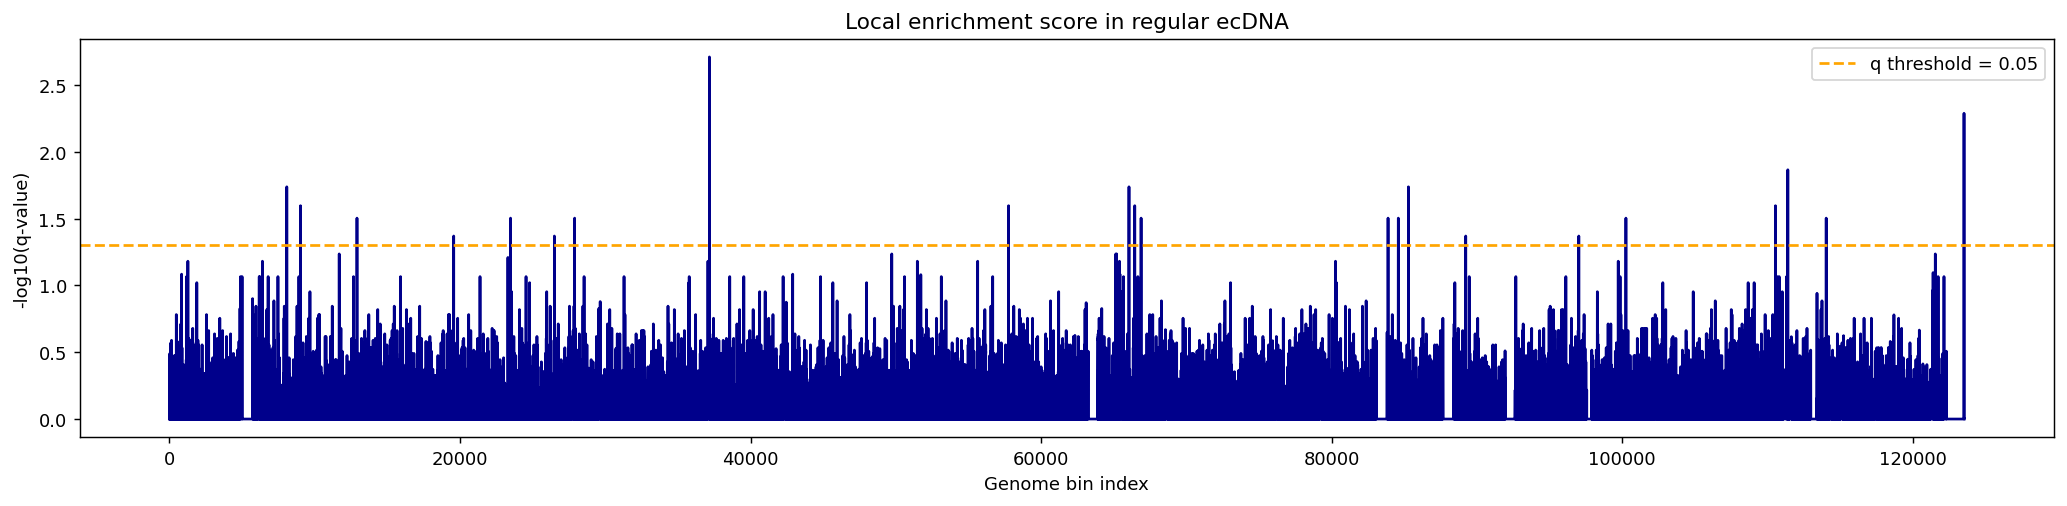

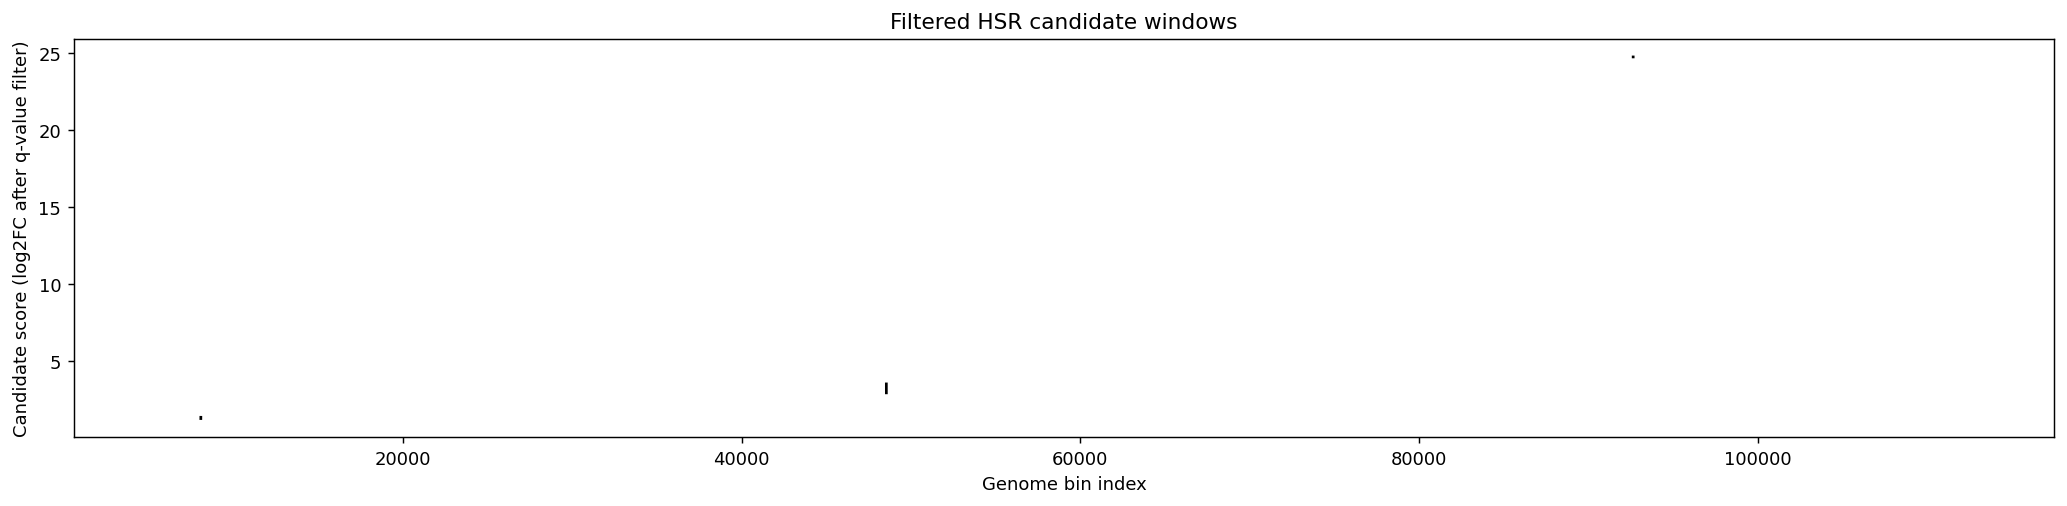

In [16]:

# =========================
# Plots
# =========================
x = np.arange(len(hsr_profile))

plt.figure(figsize=(16, 4))
plt.plot(x, hsr_profile, label="HSR ecDNA→genome profile", alpha=0.9)
plt.plot(x, reg_profile, label="Regular ecDNA→genome profile", alpha=0.9)
plt.xlabel("Genome bin index")
plt.ylabel(f"Mean normalized interaction across ecDNA bins ({BALANCE})")
plt.title("Genome-wide ecDNA→genome interaction profiles")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "profiles_hsr_vs_reg.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, per_bin_log2fc, color="purple")
plt.axhline(0, linestyle="--", color="gray")
plt.axhline(LOG2FC_THRESHOLD, linestyle="--", color="orange", label=f"log2FC threshold = {LOG2FC_THRESHOLD}")
plt.xlabel("Genome bin index")
plt.ylabel("log2(HSR / regular)")
plt.title("Per-bin HSR vs regular log2 fold change")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "per_bin_log2fc_hsr_vs_reg.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, hsr_stats["neglog10q"], color="darkred")
plt.axhline(-np.log10(QVAL_THRESHOLD), linestyle="--", color="orange",
            label=f"q threshold = {QVAL_THRESHOLD}")
plt.xlabel("Genome bin index")
plt.ylabel("-log10(q-value)")
plt.title("Local enrichment score in HSR")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_neglog10q.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, reg_stats["neglog10q"], color="darkblue")
plt.axhline(-np.log10(QVAL_THRESHOLD), linestyle="--", color="orange",
            label=f"q threshold = {QVAL_THRESHOLD}")
plt.xlabel("Genome bin index")
plt.ylabel("-log10(q-value)")
plt.title("Local enrichment score in regular ecDNA")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "reg_neglog10q.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, np.where(candidate_mask, window_log2fc, np.nan), color="black")
plt.xlabel("Genome bin index")
plt.ylabel("Candidate score (log2FC after q-value filter)")
plt.title("Filtered HSR candidate windows")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "filtered_hsr_candidates.png"), dpi=200)
plt.show()
